In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering_invariant import AgglomerativeClustering
from utils import generate_null_data, compute_nu, naive_p_value_random_pair, check_p_value_uniformity
import sklearn.cluster as cluster
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stats
from scipy.special import gamma
from scipy.stats import multivariate_normal,f
import random

In [9]:
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster

def wcss_from_labels(X, labels):
    """Compute WCSS given cluster labels."""
    wcss = 0
    for k in np.unique(labels):
        cluster_points = X[labels == k]
        center = cluster_points.mean(axis=0)
        wcss += ((cluster_points - center) ** 2).sum()
    return wcss

def compute_wcss_hclust(X, n_clusters, method="ward"):
    """Deterministic hierarchical clustering WCSS for given K."""
    Z = linkage(X, method=method)  # e.g. 'ward', 'complete', 'average'
    labels = fcluster(Z, n_clusters, criterion="maxclust")
    return wcss_from_labels(X, labels)

def gap_statistic(X, K_max=10, B=50, method="ward", random_state=None):
    """
    Deterministic Gap Statistic (Tibshirani et al. 2001) using hierarchical clustering.

    Parameters
    ----------
    X : array, shape (n_samples, n_features)
        Input data
    K_max : int
        Max number of clusters to consider
    B : int
        Number of bootstrap reference datasets
    method : str
        Linkage method ('ward', 'complete', 'average', etc.)
    random_state : int or None

    Returns
    -------
    best_K : int
        Estimated number of clusters (hat{K})
    gaps : np.array
        Gap values for K = 1..K_max
    sk : np.array
        Standard error for each K
    """
    n, p = X.shape
    rng = np.random.RandomState(random_state)

    mins = X.min(axis=0)
    maxs = X.max(axis=0)

    log_wcss = np.zeros(K_max)
    gap = np.zeros(K_max)
    sk = np.zeros(K_max)

    for k in range(1, K_max + 1):
        wk = compute_wcss_hclust(X, k, method=method)
        log_wcss[k - 1] = np.log(wk)
        wk_refs = np.zeros(B)
        for b in range(B):
            X_ref = rng.uniform(mins, maxs, size=X.shape)
            wk_refs[b] = compute_wcss_hclust(X_ref, k, method=method)
        log_wk_refs = np.log(wk_refs)

        gap[k - 1] = np.mean(log_wk_refs) - log_wcss[k - 1]
        sk[k - 1] = np.std(log_wk_refs) * np.sqrt(1 + 1 / B)

    for k in range(1, K_max):
        if gap[k - 1] >= gap[k] - sk[k]:
            return k, gap, sk
    return K_max, gap, sk


In [10]:
X,y = make_blobs(n_samples=30, n_features=2, centers=3)
gap_statistic(X, K_max=30, B=50)

(3,
 array([-0.47448997,  0.29269445,  1.48737094,  1.25592277,  1.09298035,
         1.02361232,  1.04564695,  0.97215857,  0.9951423 ,  1.03118047,
         1.09780332,  1.05308014,  0.96844582,  0.92497032,  0.92472421,
         0.9461106 ,  0.90077437,  0.84613552,  0.84696842,  0.83120908,
         0.77074904,  0.79411773,  0.75467341,  0.59735204,  0.60212636,
         0.45332037,  0.35580176,  0.28496567,  0.17594428,  0.37128228]),
 array([0.13356629, 0.15794785, 0.12469775, 0.15569759, 0.16130945,
        0.19532659, 0.15689971, 0.17715895, 0.20133326, 0.21479032,
        0.17839006, 0.16673771, 0.20805668, 0.24019432, 0.20465568,
        0.26292535, 0.29400894, 0.2905594 , 0.3010265 , 0.28564237,
        0.37462225, 0.36876927, 0.34752016, 0.47735425, 0.48413673,
        0.58652895, 0.63889665, 0.87094866, 0.72109799, 0.7914647 ]))

1e-05 10.382299422217248
1e-05 11.011273879908659
1e-05 22.246504081820532
1e-05 7.750271573621278
1e-05 16.4273476472
1e-05 7.617441932295149
1e-05 15.089167356126923
1e-05 16.586083870587206
1e-05 8.11421076384662
1e-05 11.310534356269496
1e-05 13.942560542946325
1e-05 13.523763063566923
1e-05 15.228079387479768
1e-05 13.10055735559359
1e-05 12.81550879586352
1e-05 18.36220998933557
1e-05 11.612131138464562
1e-05 14.604536713956008
1e-05 14.554637276471855
1e-05 16.429057241286728
1e-05 22.120405918957903
1e-05 14.575353961336083
1e-05 9.716108958348386
1e-05 13.34497967900818
1e-05 11.842340384572218
1e-05 11.379215124012159
1e-05 14.500880032948286
1e-05 9.391361125732377
1e-05 10.147173544859589
1e-05 18.550218677732246
1e-05 14.017384407941066
1e-05 12.191948382045247
1e-05 12.473976755179503
1e-05 21.18876475227241
1e-05 18.410892515495814
1e-05 9.588399409680992
1e-05 7.957979924884551
1e-05 12.69735146439507
1e-05 12.544657712025675
1e-05 11.077202566282901
1e-05 13.8091788744

/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/utils.py:107: RuntimeWarning: invalid value encountered in scalar divide
  observed_target = (m - 2) * np.linalg.norm(P0 @ X, 'fro') ** 2 / np.linalg.norm(P1 @ X, 'fro') ** 2


1e-05 8.310624103100514
1e-05 7.578945711976007
1e-05 13.123914612932364
1e-05 8.216403807367143
1e-05 13.67874380514915
1e-05 8.08429686406443
1e-05 14.256763609614698
1e-05 13.552947970837092
1e-05 13.698289996506428
1e-05 10.40307800224086
1e-05 14.574132280765419
1e-05 17.425780177992287
1e-05 16.2002585009265
1e-05 12.312945392207626
1e-05 10.374768268686768
1e-05 11.792590799068861
1e-05 10.7094289749173
1e-05 12.88161550074457
1e-05 15.685405115938334
1e-05 10.556161812442307
1e-05 14.850852557724327
1e-05 8.261067951439447


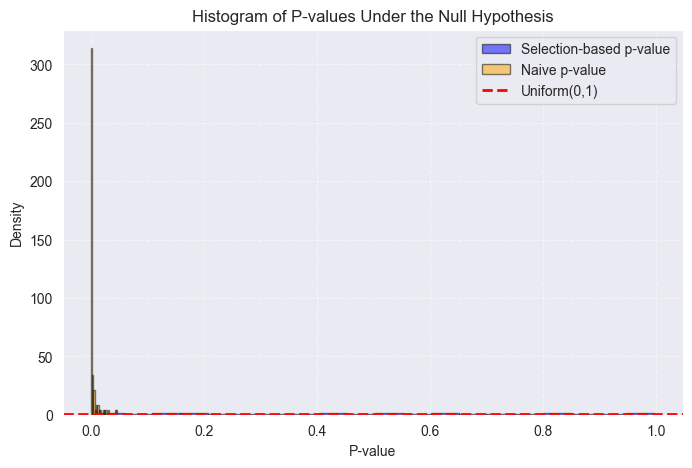

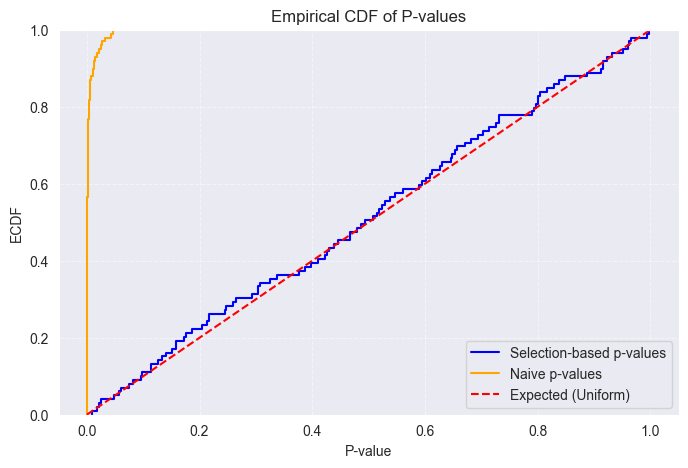

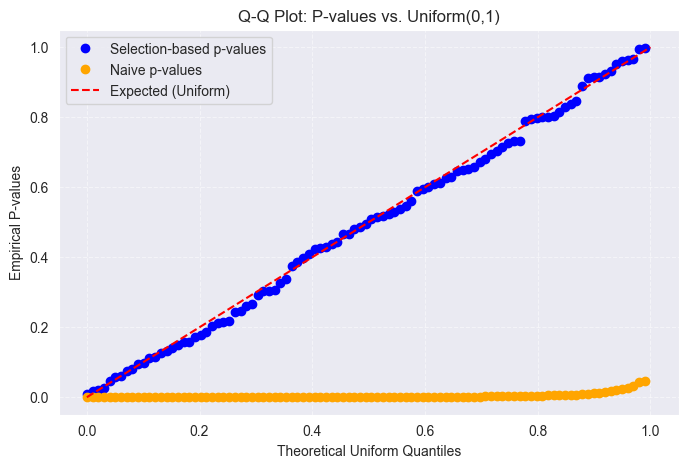

In [4]:
check_p_value_uniformity(30,10,1,3,0.05,-1,num_trials=100)

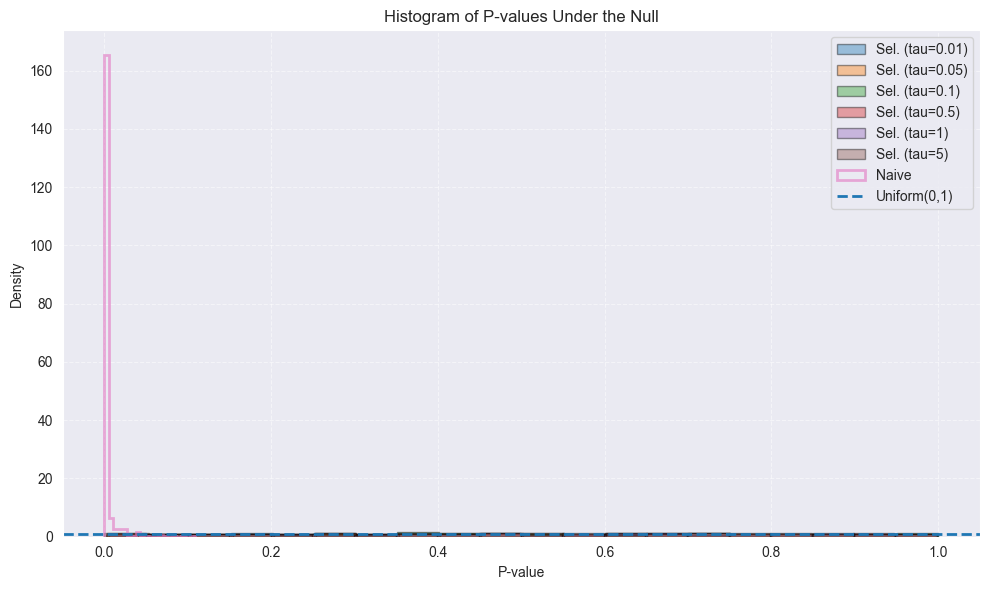

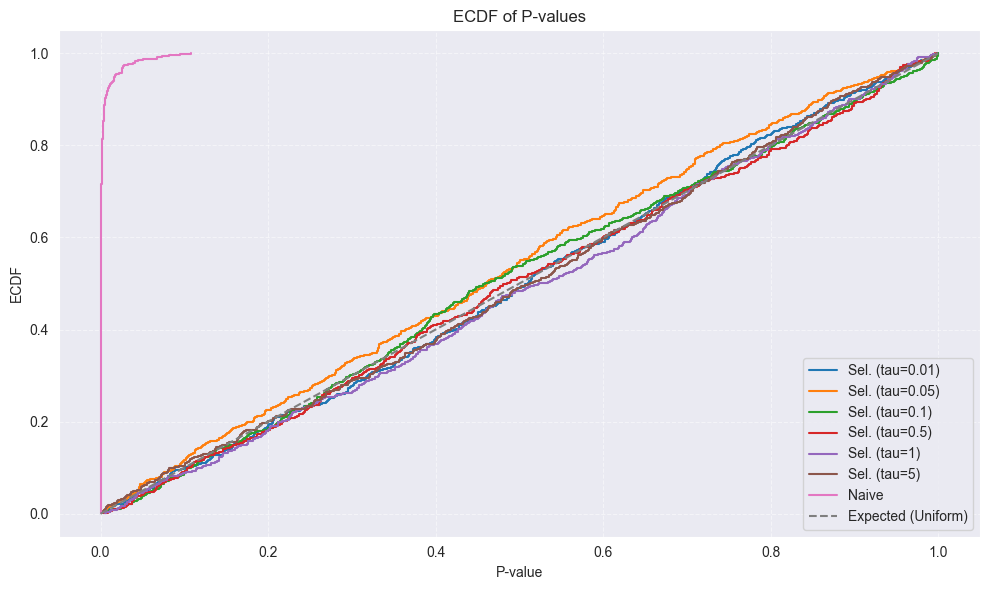

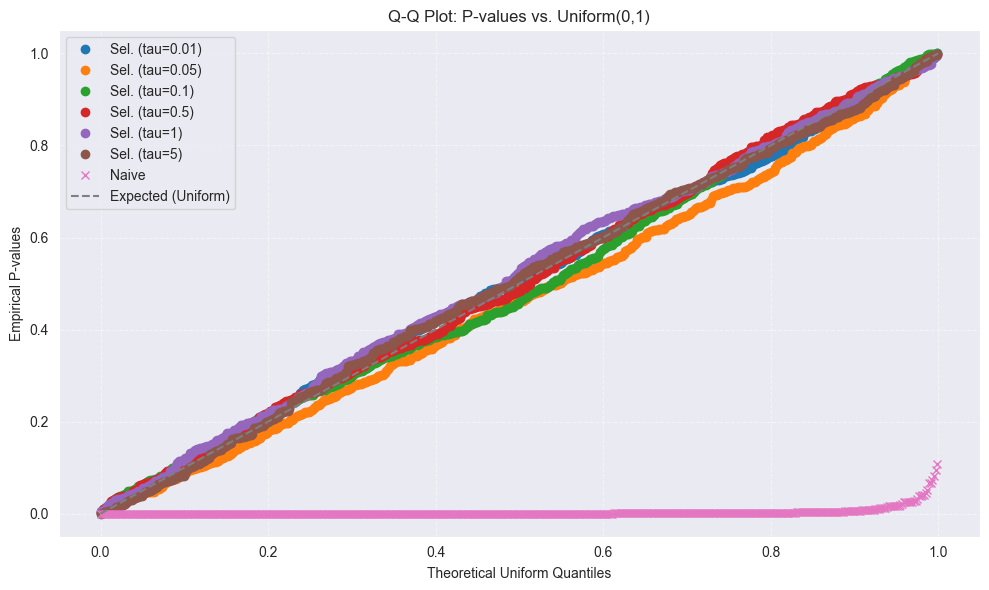

In [3]:
df = pd.read_csv("/Users/judydw/Downloads/pval_data_randomized-6.csv")
tau_cols = [c for c in df.columns if c.startswith('tau=')]
naive = df['naive'].dropna().to_numpy()
plt.figure(figsize=(10, 6))
for col in tau_cols:
    vals = df[col].dropna().to_numpy()
    plt.hist(vals, bins=20, density=True, alpha=0.4, edgecolor='black',
             label=f"Sel. ({col})")
plt.hist(naive, bins=20, density=True, alpha=0.6, histtype='step', linewidth=2,
         label="Naive")
plt.axhline(1, linestyle='--', linewidth=2, label="Uniform(0,1)")
plt.xlabel("P-value"); plt.ylabel("Density")
plt.title("Histogram of P-values Under the Null")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

def plot_ecdf(values, label):
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.step(x, y, where='post', label=label)

plt.figure(figsize=(10, 6))
for col in tau_cols:
    plot_ecdf(df[col].dropna().to_numpy(), f"Sel. ({col})")
plot_ecdf(naive, "Naive")
plt.plot([0, 1], [0, 1], linestyle="--", label="Expected (Uniform)")
plt.xlabel("P-value"); plt.ylabel("ECDF")
plt.title("ECDF of P-values")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 6))
for col in tau_cols:
    vals = np.sort(df[col].dropna().to_numpy())
    n = len(vals)
    theo = (np.arange(1, n + 1) - 0.5) / n
    plt.plot(theo, vals, marker='o', linestyle='', label=f"Sel. ({col})")
vals_naive = np.sort(naive)
#vals_gao_c = np.sort(gao_c)
n0 = len(vals_naive)
theo0 = (np.arange(1, n0 + 1) - 0.5) / n0
plt.plot(theo0, vals_naive, marker='x', linestyle='', label="Naive")
#plt.plot(theo0, vals_gao_c, marker='x', linestyle='', label="Gao et al.(sigma_clustered)")
plt.plot([0, 1], [0, 1], linestyle="--", label="Expected (Uniform)")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical P-values")
plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

In [11]:
random.seed(0)
p= 10
mu = np.zeros(p)
X = generate_null_data(30,p,mu,1)

grid_width = 20
model = AgglomerativeClustering(X, tau=0.01, n_clusters=3, linkage="complete")
model.fit()
c1 = model.K_clusters[0]
c2 = model.K_clusters[1]
m = len(c1.points) + len(c2.points)
dfn = p
dfd = p* (m-2)

p_val, obs, sel_prob,low,high = model.merge_inference_F_random_pair_grid(c1,c2,grid_width=grid_width, ncoarse = 20, ngrid=2000)
p_val1, obs1, sel_prob1 = model.merge_inference_F_random_pair(c1,c2,grid_width=grid_width, ncoarse = 20, ngrid=2000)
grid = np.linspace(0.00001, grid_width, num=2000)
grid_short = np.linspace(low, high, 2000)
uncorrected = f.pdf(grid,dfn, dfd)
sel_log = np.asarray(sel_prob).reshape(-1)
assert sel_log.shape[0] == grid.shape[0]

log_prior = f.logpdf(grid, dfn, dfd)           
log_post  = log_prior + sel_log              
dx      = np.gradient(grid)
unnorm  = np.exp(log_post - log_post.max())
Z       = (unnorm * dx).sum() + 1e-300
corr_pdf = unnorm / Z                       

sel_log1 = np.asarray(sel_prob1).reshape(-1)
assert sel_log1.shape[0] == grid.shape[0]
       
log_post1  = log_prior + sel_log1   
unnorm1  = np.exp(log_post1 - log_post1.max())
Z1       = (unnorm1 * dx).sum() + 1e-300
corr_pdf1 = unnorm1 / Z1

plt.figure(figsize=(8,5))
plt.plot(grid, f.pdf(grid, dfn, dfd), label='uncorrected F', alpha=0.8)
plt.plot(grid_short, corr_pdf, label='selection-corrected (normalized, short)', linewidth=2)

plt.plot(grid, corr_pdf1, label='selection-corrected (normalized)', linewidth=2)
plt.axvline(obs, ls='--', color='k', alpha=0.7, label=f'observed = {obs:.3g}')

mask = grid_short >= obs
plt.fill_between(grid_short[mask], 0, corr_pdf[mask], alpha=0.25, label=f'corrected tail ≈ {p_val:.3f}')

plt.xlabel('F-statistic (g)')
plt.ylabel('density')
plt.title('F vs. selection-corrected density')
plt.legend()
plt.tight_layout()
plt.show()

1e-05 7.012367998197821


ValueError: not enough values to unpack (expected 5, got 3)

In [3]:
p_val

np.float64(0.7140258687450719)

In [4]:
w  = corr_pdf * dx
cdf = np.cumsum(w)
cdf /= cdf[-1]
q_low, q_high = 0.005, 0.995
low  = np.interp(q_low,  cdf, grid)
high = np.interp(q_high, cdf, grid)
print(low, high)

7.550100805211367 11.012673516747547


In [4]:
def check_p_value_uniformity(n, p, sigma, K, tau, linkage="complete", num_trials=1000):
    p_values = []
    p_values_n = []
    mu = np.zeros(p)

    while len(p_values_n) < num_trials:
        X = generate_null_data(n, p, mu, sigma)
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K, linkage=linkage)
        model.fit()

        c1 = model.K_clusters[0]
        c2 = model.K_clusters[1]
        p_value, obs,sel_prob = model.merge_inference_F_random_pair_grid(c1,c2, grid_width=70, ncoarse=20, ngrid=2000) 
        p_value_n = naive_p_value_random_pair(X, K, linkage)
        if not (np.isnan(p_value) and np.isnan(p_value_n)):
            p_values.append(p_value)
            p_values_n.append(p_value_n)
    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="Selection-based p-value")
    plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.ecdfplot(p_values, color="blue", label="Selection-based p-values")
    sns.ecdfplot(p_values_n, color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("P-value")
    plt.ylabel("ECDF")
    plt.title("Empirical CDF of P-values")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue",
             label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

7.402748204828004 55.498715096954314
19.866093350650907 70.0
2.327471080349172 28.938865210329098
6.7736556160951 26.261827411098704
3.271961770802399 56.22854434930738
2.024396481003027 59.3335767362782
5.270282636867083 53.861145497658825
10.112650517726802 60.39431364475622
0.2659846492226876 43.1183526076086
2.2699467958371393 40.1029781901386
1e-05 29.114375932731516
5.151793143882102 50.937404962476236
0.03220334858179186 40.79713870033301
1e-05 46.06215627692743
4.313190037723826 24.919448188485802
1.2985504433540136 39.95099793757082
1.8937150319227989 8.833566633150292
1e-05 39.169468876772704
1e-05 26.167472059592512
1e-05 36.51818025709082
1.46647216504768 48.643558156247074
3.698214861328335 39.876624483180265
1.48045410612335 24.199146124833042
0.04115449616859035 19.400159897432086
1e-05 29.5529702300801
1e-05 34.29705097311712
1e-05 41.79453809221898
0.05943741874493824 41.0168644748761
2.186079881121234 39.30380649450615
1e-05 21.90363787935558
1e-05 47.71948578066722
2

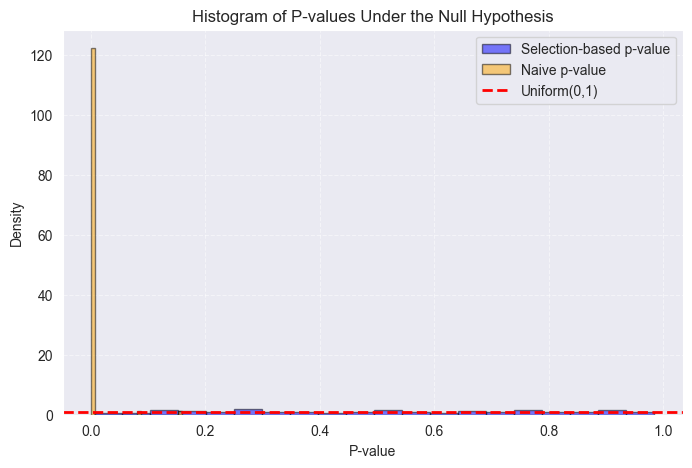

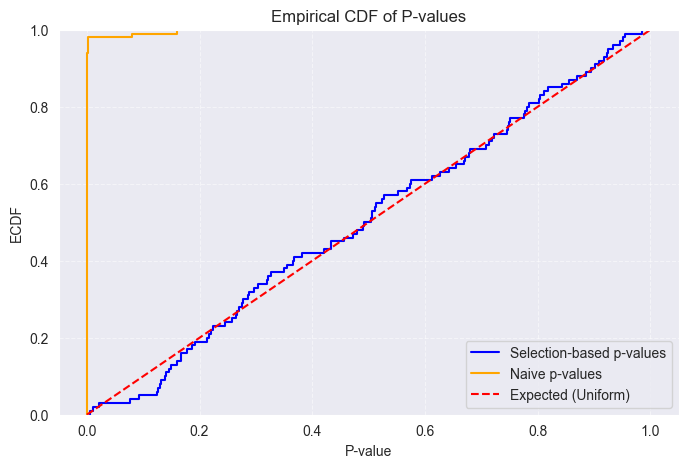

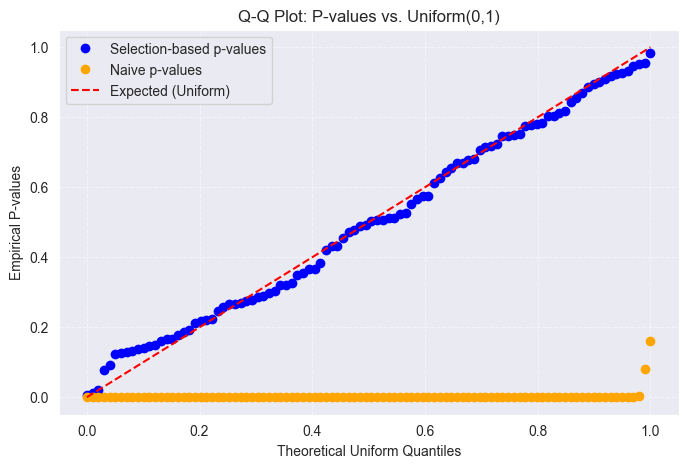

In [6]:
check_p_value_uniformity(30,2,1,3,0.01,"complete", 100)

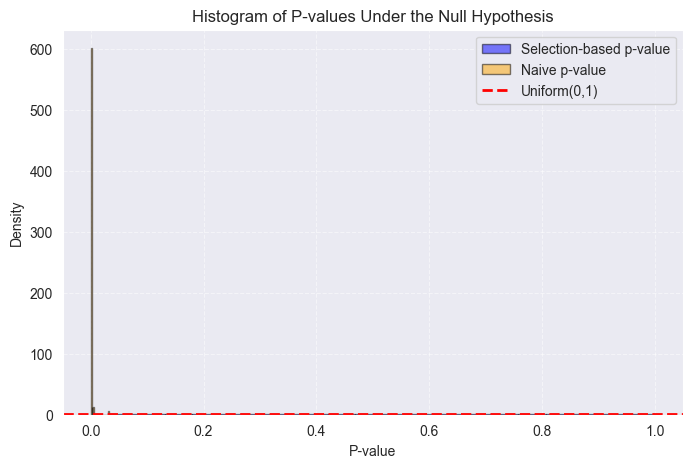

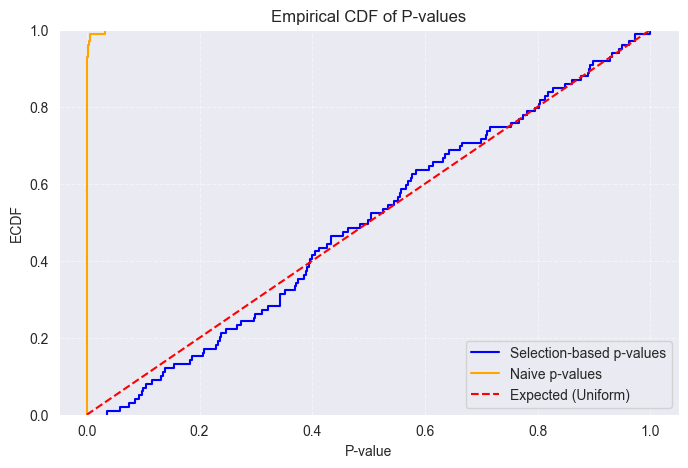

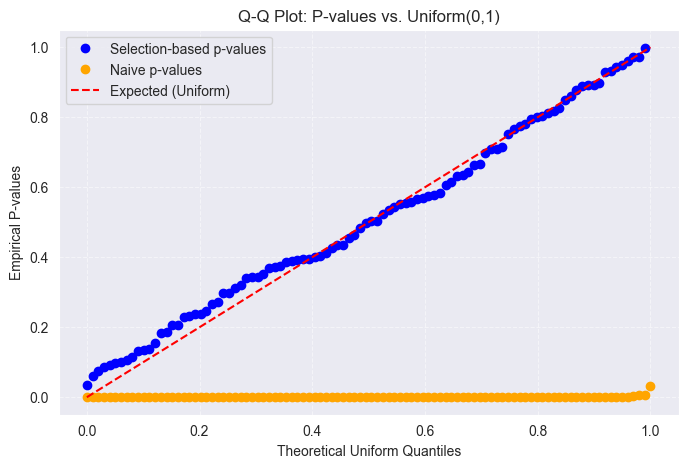

In [9]:
check_p_value_uniformity(30,2,1,3,0.01,"complete", 100)